# Exploratory Data Analysis

## Student Health Risk Prediction

### Objective

This notebook performs exploratory data analysis on the student health risk dataset to identify data-quality issues, class imbalance, missing-value patterns, numerical distributions, potential outliers, categorical patterns, and relationships between predictor variables and the target variable.

The analysis is intended to influence subsequent preprocessing and model-design decisions for four classification approaches:

1. Logistic Regression
2. Random Forest
3. Support Vector Machine
4. Multi-Layer Perceptron Neural Network

Particular attention is given to class imbalance and missing data because the initial dataset inspection identified a dominant target class and substantial feature-level missingness.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("EDA libraries imported successfully.")

EDA libraries imported successfully.


In [62]:
PROJECT_ROOT = Path.cwd().parent

TRAIN_PATH = PROJECT_ROOT / "data" / "raw" / "train.csv"

train_df = pd.read_csv(TRAIN_PATH)

TARGET = "health_condition"
ID_COLUMN = "id"

print("Training dataset loaded successfully.")
print("Shape:", train_df.shape)

Training dataset loaded successfully.
Shape: (690088, 15)


In [63]:
numerical_features = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]

categorical_features = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 7
Number of categorical features: 6


In [64]:
target_counts = train_df[TARGET].value_counts()

target_percentages = (
    train_df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_distribution = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

target_distribution

,Count,Percentage
health_condition,,
at-risk,592561,85.87
unhealthy,57724,8.36
fit,39803,5.77


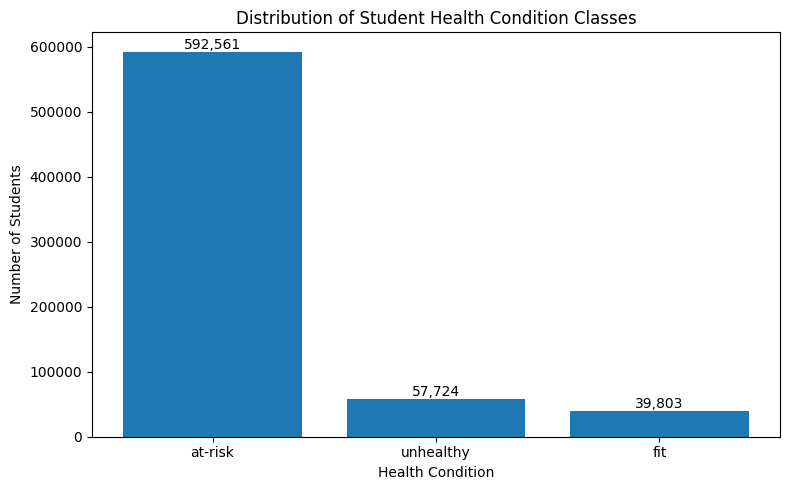

In [65]:
target_order = ["at-risk", "unhealthy", "fit"]

target_counts_ordered = (
    train_df[TARGET]
    .value_counts()
    .reindex(target_order)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    target_counts_ordered.index,
    target_counts_ordered.values
)

ax.set_title("Distribution of Student Health Condition Classes")
ax.set_xlabel("Health Condition")
ax.set_ylabel("Number of Students")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

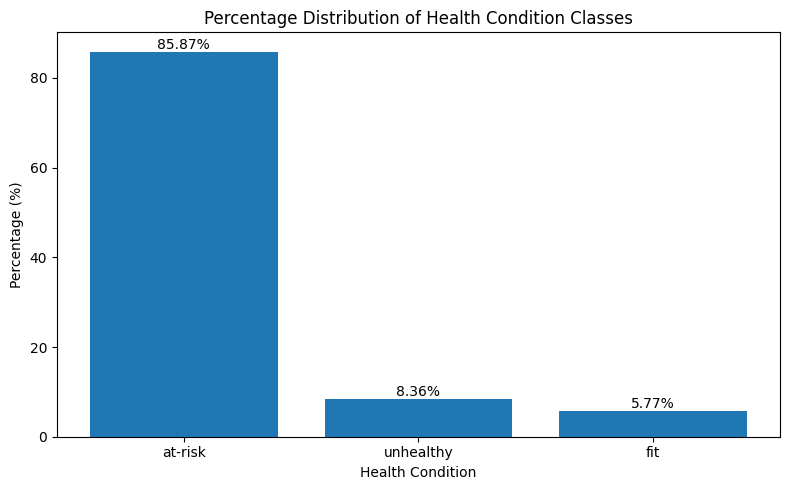

In [66]:
target_percentage_ordered = (
    train_df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(target_order)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    target_percentage_ordered.index,
    target_percentage_ordered.values
)

ax.set_title("Percentage Distribution of Health Condition Classes")
ax.set_xlabel("Health Condition")
ax.set_ylabel("Percentage (%)")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Target Distribution Interpretation

The target variable exhibits severe class imbalance. The `at-risk` category represents 85.87% of the training observations, whereas `unhealthy` and `fit` account for only 8.36% and 5.77%, respectively.

This imbalance has direct implications for model evaluation. A classifier that performs strongly on the majority class may achieve high overall accuracy while providing substantially weaker detection of minority classes. Therefore, overall accuracy alone is not considered sufficient for model selection.

The project will additionally evaluate balanced accuracy, macro-averaged precision, macro-averaged recall, macro F1-score, class-wise performance, and confusion matrices. Class weighting and other imbalance-aware strategies will be considered during model development where technically appropriate.

In [67]:
missing_summary = pd.DataFrame({
    "Missing Count": train_df.isnull().sum(),
    "Missing Percentage": (
        train_df.isnull().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary[
        missing_summary["Missing Count"] > 0
    ]
    .sort_values(
        by="Missing Percentage",
        ascending=False
    )
)

missing_summary

,Missing Count,Missing Percentage
stress_level,82811,12.00
sleep_duration,75999,11.01
sleep_quality,58331,8.45
calorie_expenditure,52853,7.66
water_intake,43477,6.30
physical_activity_level,36621,5.31
smoking_alcohol,28582,4.14
gender,21373,3.10
step_count,13916,2.02
bmi,13898,2.01


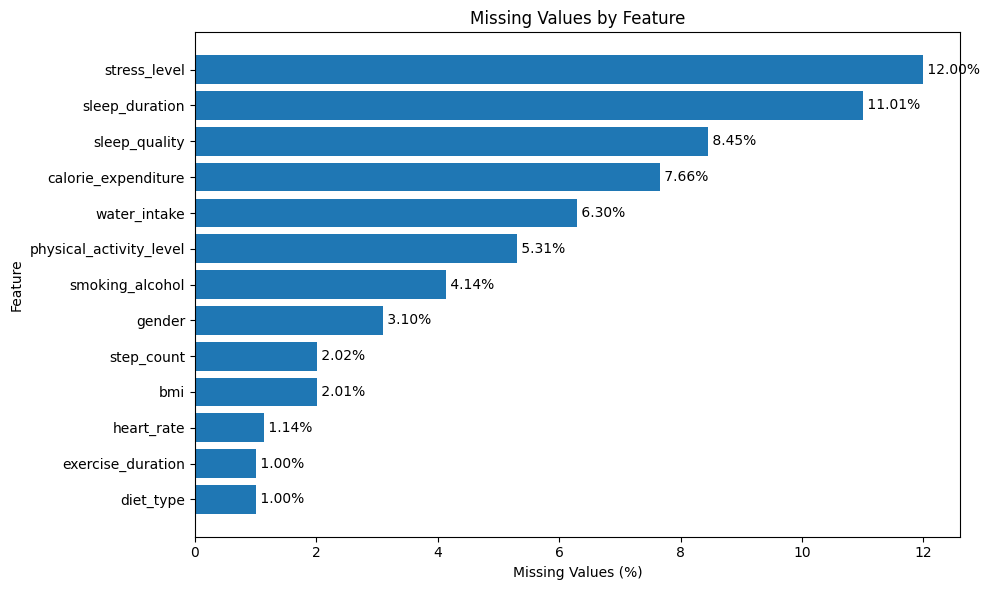

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    missing_summary.index,
    missing_summary["Missing Percentage"]
)

ax.set_title("Missing Values by Feature")
ax.set_xlabel("Missing Values (%)")
ax.set_ylabel("Feature")

ax.invert_yaxis()

for i, value in enumerate(
    missing_summary["Missing Percentage"]
):
    ax.text(
        value,
        i,
        f" {value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [69]:
total_missing = train_df.isnull().sum().sum()
total_cells = train_df.shape[0] * train_df.shape[1]

overall_missing_percentage = (
    total_missing / total_cells
) * 100

print("Total Missing Values:", f"{total_missing:,}")
print(
    "Overall Missing Percentage:",
    f"{overall_missing_percentage:.2f}%"
)

Total Missing Values: 449,496
Overall Missing Percentage: 4.34%


### Missing-Value Interpretation

The dataset contains 449,496 missing cells, representing approximately 4.34% of all values. Missingness is unevenly distributed across features. The highest missing percentages occur in `stress_level` (12.00%), `sleep_duration` (11.01%), and `sleep_quality` (8.45%).

Removing every incomplete row could discard a substantial amount of potentially useful training information. Therefore, the subsequent preprocessing stage will investigate imputation rather than unrestricted row deletion.

For numerical variables, median imputation is a suitable initial strategy because it is less sensitive to extreme observations than mean imputation. For categorical variables, most-frequent imputation provides an interpretable baseline. These preprocessing decisions will be implemented inside reproducible model pipelines to reduce the risk of data leakage.

In [70]:
numerical_summary = train_df[
    numerical_features
].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


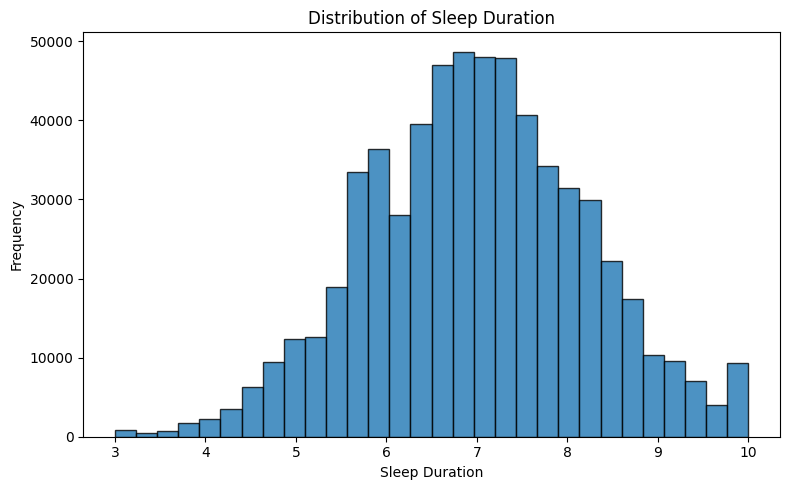

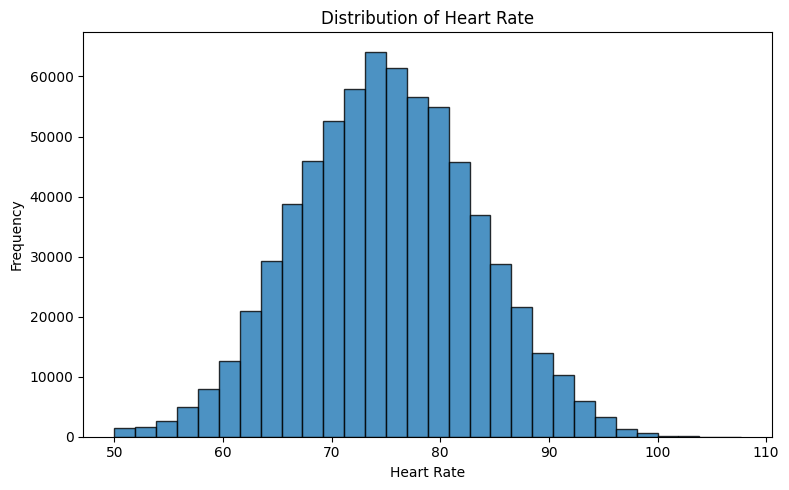

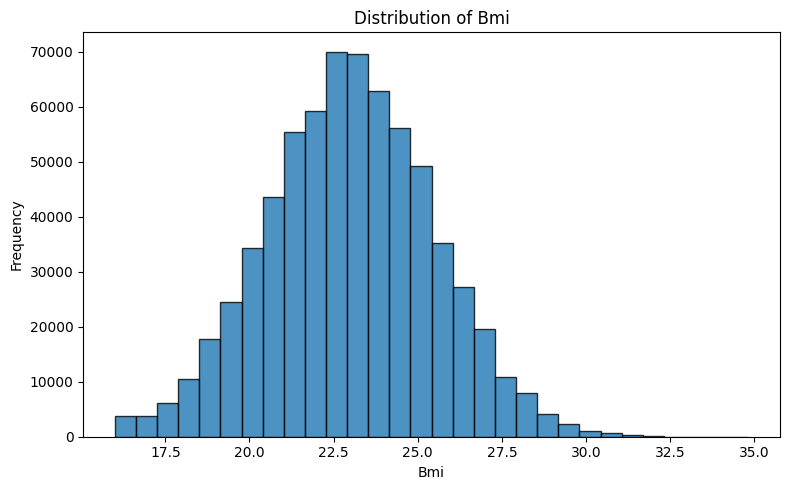

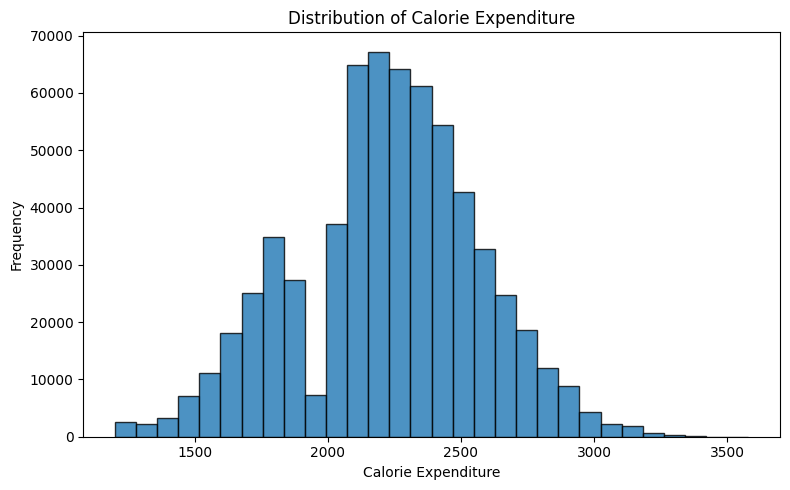

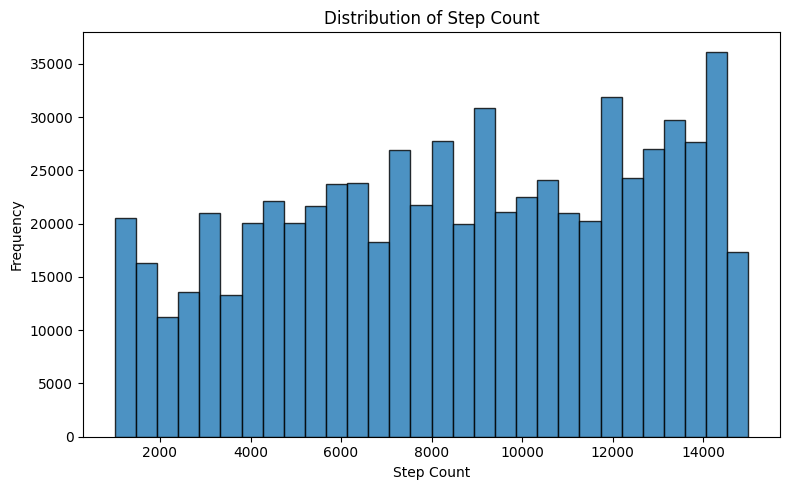

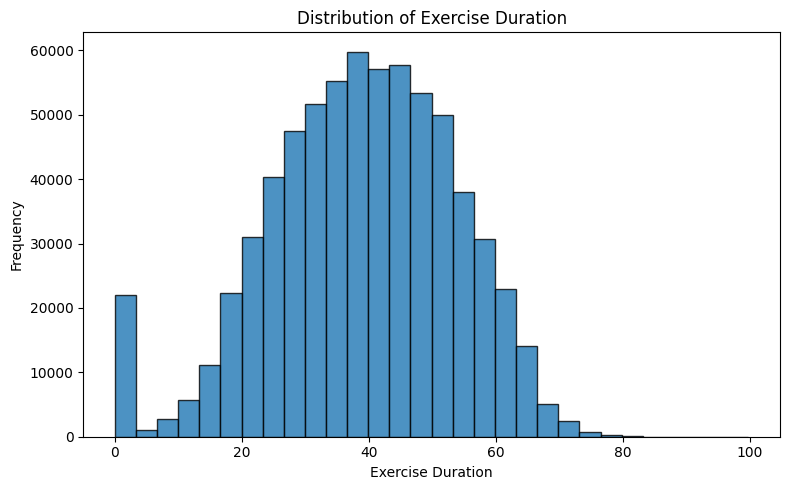

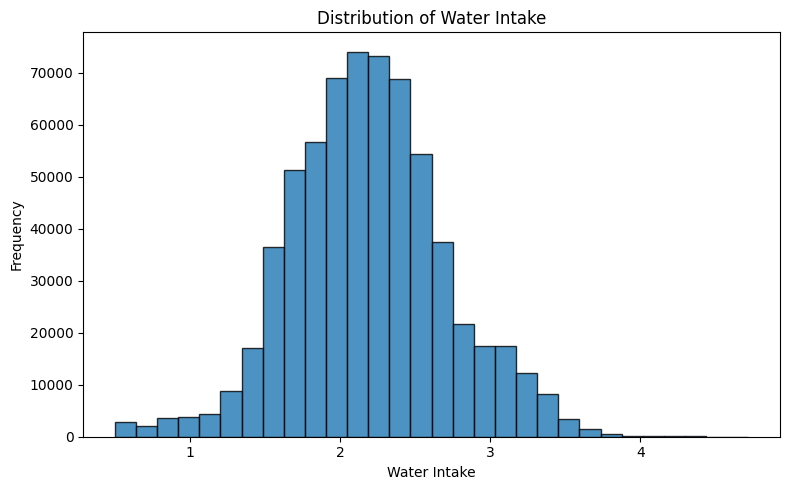

In [71]:
for feature in numerical_features:
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(
        train_df[feature].dropna(),
        bins=30,
        edgecolor="black",
        alpha=0.8
    )

    ax.set_title(
        f"Distribution of {feature.replace('_', ' ').title()}"
    )
    ax.set_xlabel(
        feature.replace("_", " ").title()
    )
    ax.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [72]:
skewness_summary = (
    train_df[numerical_features]
    .skew()
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
    .to_frame(name="Skewness")
)

skewness_summary

,Skewness
exercise_duration,-0.374610
calorie_expenditure,-0.183940
step_count,-0.180238
water_intake,0.109960
bmi,0.024640
sleep_duration,-0.008232
heart_rate,0.000438


In [73]:
distribution_stats = pd.DataFrame({
    "Mean": train_df[numerical_features].mean(),
    "Median": train_df[numerical_features].median(),
    "Std Dev": train_df[numerical_features].std(),
    "Skewness": train_df[numerical_features].skew()
}).round(3)

distribution_stats

,Mean,Median,Std Dev,Skewness
sleep_duration,6.993,6.99,1.215,-0.008
heart_rate,75.097,75.10,8.175,0.000
bmi,22.985,22.99,2.482,0.025
calorie_expenditure,2226.085,2241.00,347.532,-0.184
step_count,8615.953,8856.00,3929.400,-0.180
exercise_duration,38.751,39.40,14.742,-0.375
water_intake,2.189,2.17,0.518,0.110


### Numerical Distribution Analysis

The numerical distributions are examined to determine whether strong skewness, unusual concentration, or extreme observations may affect model development. This analysis is particularly important for Logistic Regression, SVM, and MLP models because these approaches can be sensitive to differences in feature scale.

The observed distributions will be considered alongside formal skewness statistics and boxplot-based outlier analysis before final preprocessing decisions are made. Standardisation is expected to be important for Logistic Regression, SVM, and MLP, whereas Random Forest is generally less dependent on feature scaling.

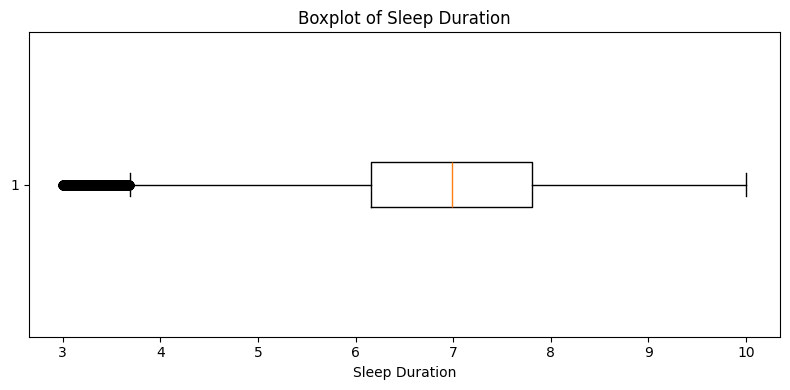

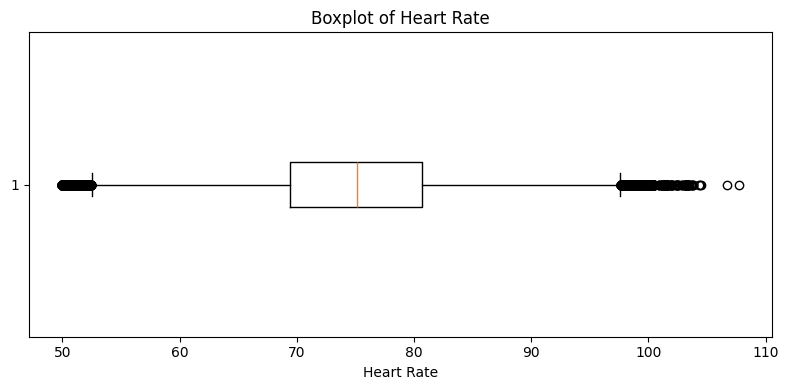

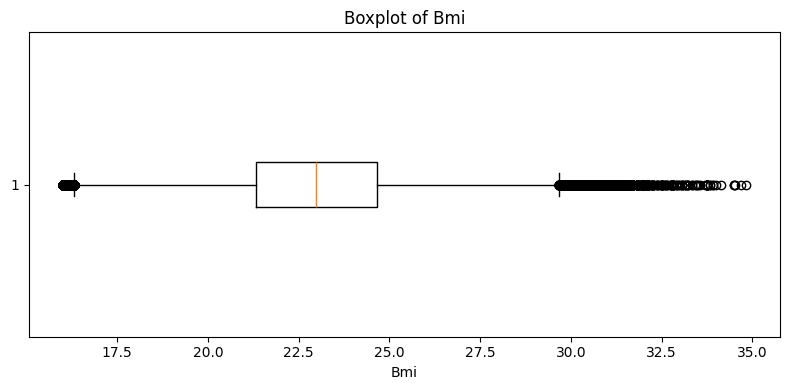

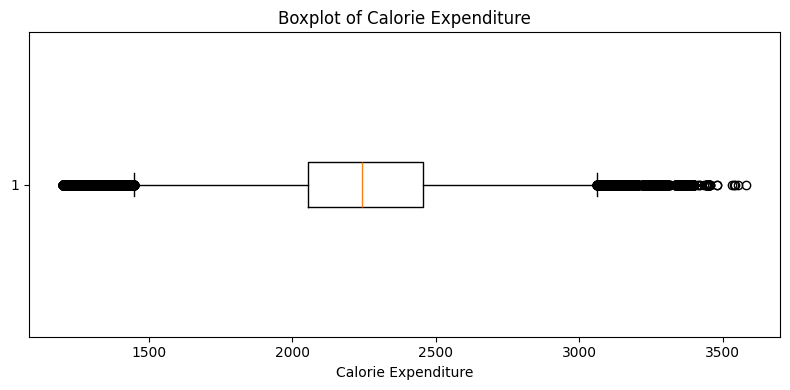

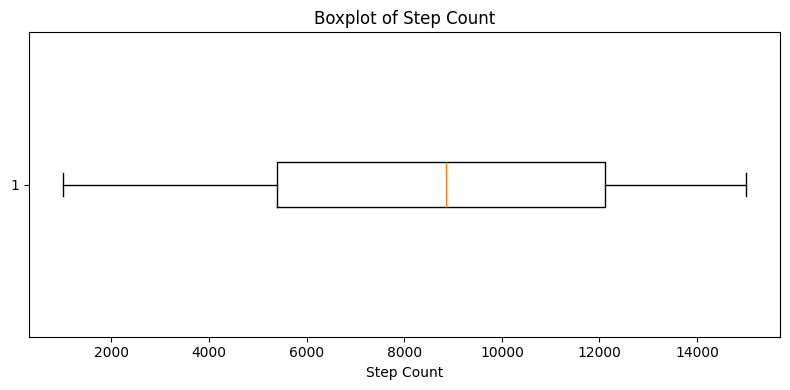

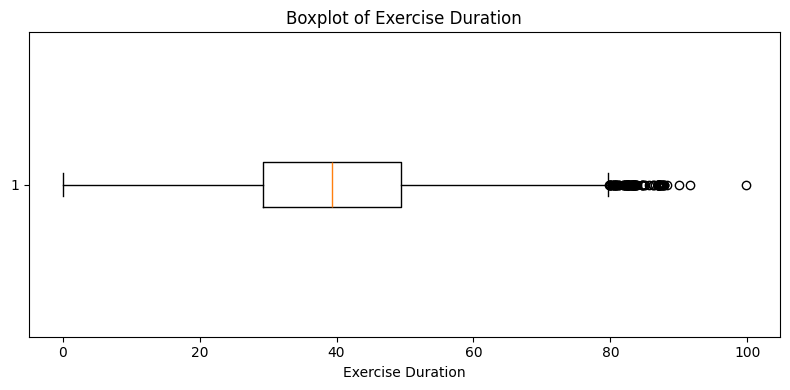

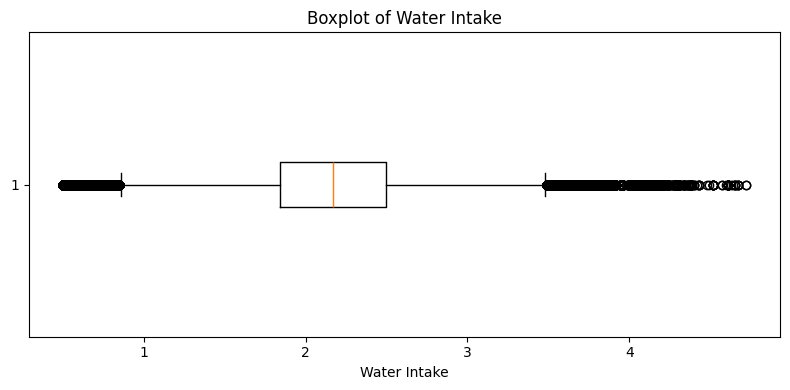

In [74]:
for feature in numerical_features:
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.boxplot(
        train_df[feature].dropna(),
        vert=False
    )

    ax.set_title(
        f"Boxplot of {feature.replace('_', ' ').title()}"
    )

    ax.set_xlabel(
        feature.replace("_", " ").title()
    )

    plt.tight_layout()
    plt.show()

In [75]:
outlier_results = []

for feature in numerical_features:
    series = train_df[feature].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (series < lower_bound) |
        (series > upper_bound)
    ).sum()

    outlier_percentage = (
        outlier_count / len(series)
    ) * 100

    outlier_results.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Potential Outliers": outlier_count,
        "Outlier Percentage": outlier_percentage
    })

outlier_summary = pd.DataFrame(
    outlier_results
).round(3)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers,Outlier Percentage
0,sleep_duration,6.16,7.81,1.65,3.685,10.285,2020,0.329
1,heart_rate,69.40,80.70,11.30,52.450,97.650,2825,0.414
2,bmi,21.32,24.66,3.34,16.310,29.670,5352,0.791
3,calorie_expenditure,2053.00,2456.00,403.00,1448.500,3060.500,12831,2.014
4,step_count,5389.00,12114.00,6725.00,-4698.500,22201.500,0,0.000
5,exercise_duration,29.20,49.40,20.20,-1.100,79.700,104,0.015
6,water_intake,1.84,2.50,0.66,0.850,3.490,11388,1.761


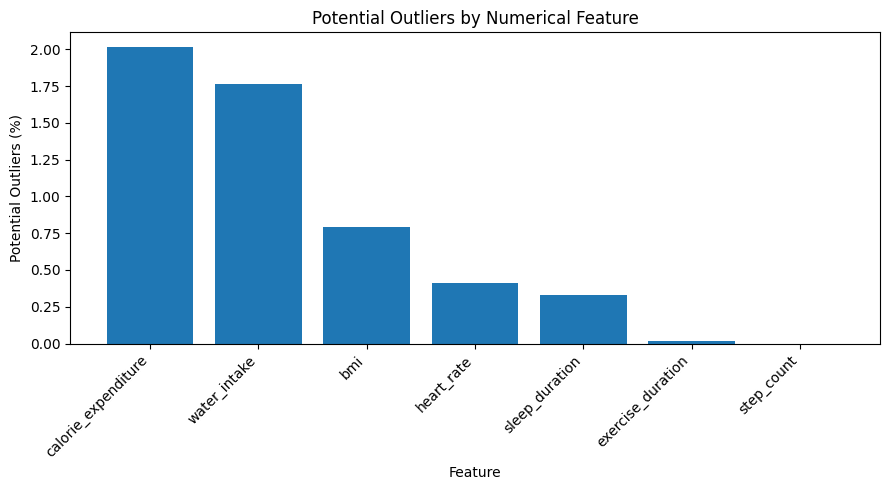

In [76]:
outlier_plot_data = (
    outlier_summary
    .sort_values(
        "Outlier Percentage",
        ascending=False
    )
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    outlier_plot_data["Feature"],
    outlier_plot_data["Outlier Percentage"]
)

ax.set_title("Potential Outliers by Numerical Feature")
ax.set_xlabel("Feature")
ax.set_ylabel("Potential Outliers (%)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Potential Outlier Analysis

Potential outliers are identified using the 1.5 × IQR rule. These observations are treated as statistical flags rather than automatically assumed to be data errors. In a health-related dataset, relatively unusual values may represent genuine variation rather than invalid records.

Consequently, observations will not be removed solely because they fall outside IQR-based thresholds. Any treatment of extreme values should consider feature plausibility, model sensitivity, and the risk of discarding informative minority-class patterns. Tree-based Random Forest models are generally more tolerant of unusual feature values, while scaling-sensitive models may require greater attention to extreme observations.

In [77]:
for feature in categorical_features:
    print("=" * 60)
    print(
        f"Feature: {feature}"
    )

    summary = pd.DataFrame({
        "Count": train_df[feature].value_counts(
            dropna=False
        ),
        "Percentage": train_df[feature]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .mul(100)
        .round(2)
    })

    display(summary)

Feature: diet_type


,Count,Percentage
diet_type,,
veg,231432,33.54
balanced,226888,32.88
non-veg,224867,32.59
NaN,6901,1.00


Feature: stress_level


,Count,Percentage
stress_level,,
medium,261819,37.94
high,177750,25.76
low,167708,24.30
NaN,82811,12.00


Feature: sleep_quality


...

,Count,Percentage
physical_activity_level,,
moderate,221041,32.03
sedentary,219784,31.85
active,212642,30.81
NaN,36621,5.31


Feature: smoking_alcohol


,Count,Percentage
smoking_alcohol,,
yes,223730,32.42
no,219791,31.85
occasional,217985,31.59
NaN,28582,4.14


Feature: gender


,Count,Percentage
gender,,
male,237756,34.45
female,224016,32.46
other,206943,29.99
NaN,21373,3.10


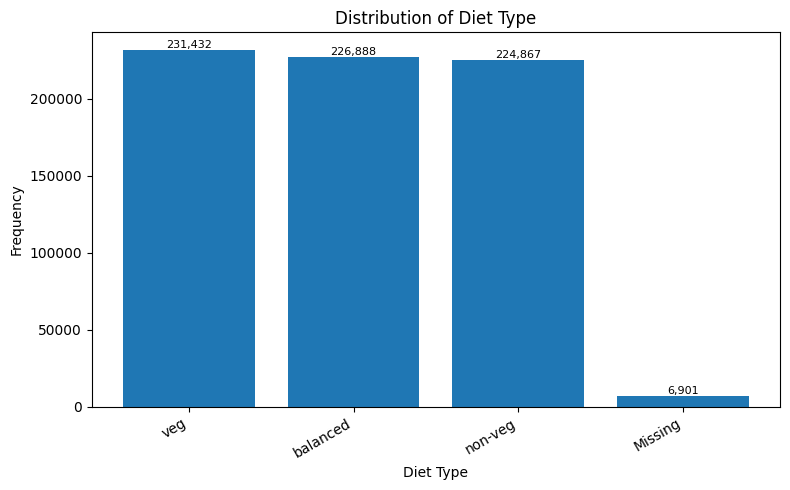

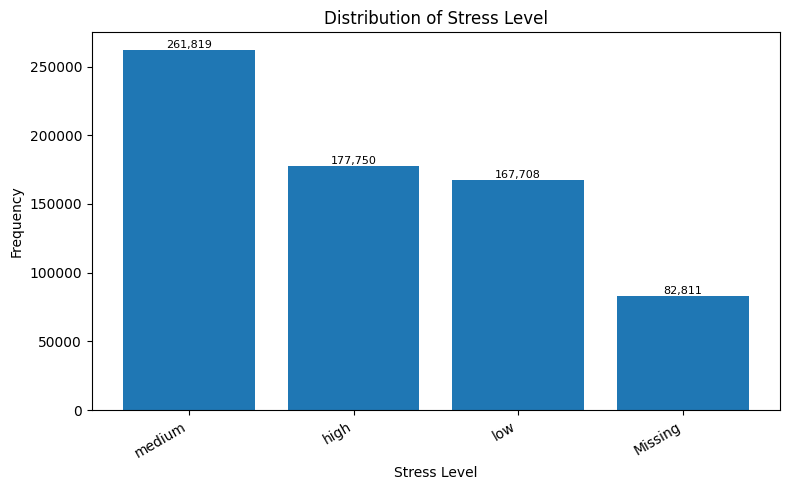

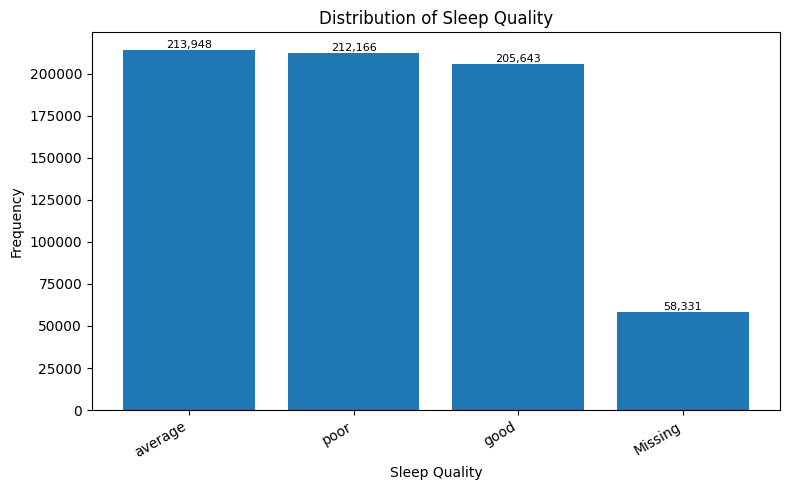

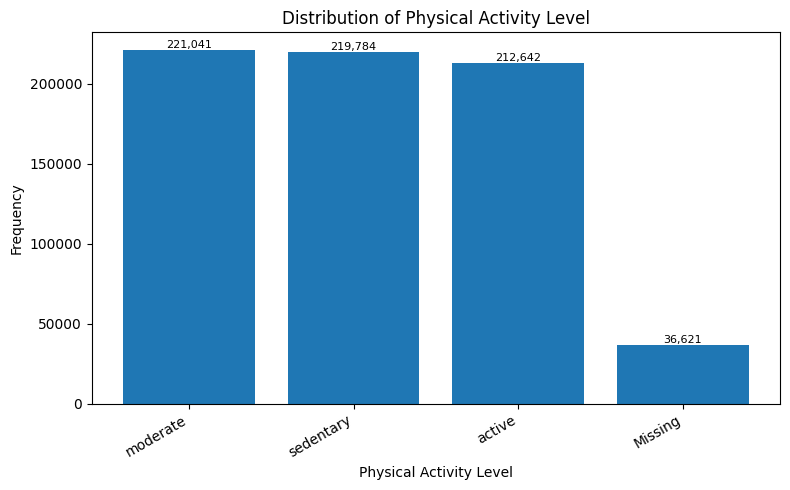

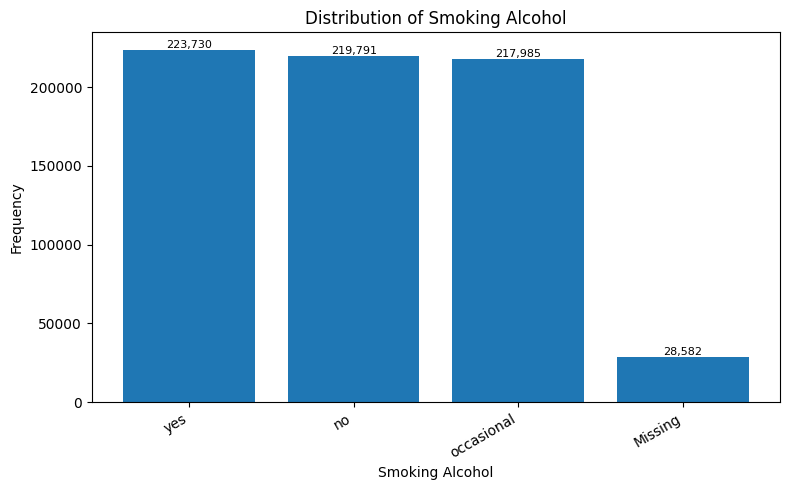

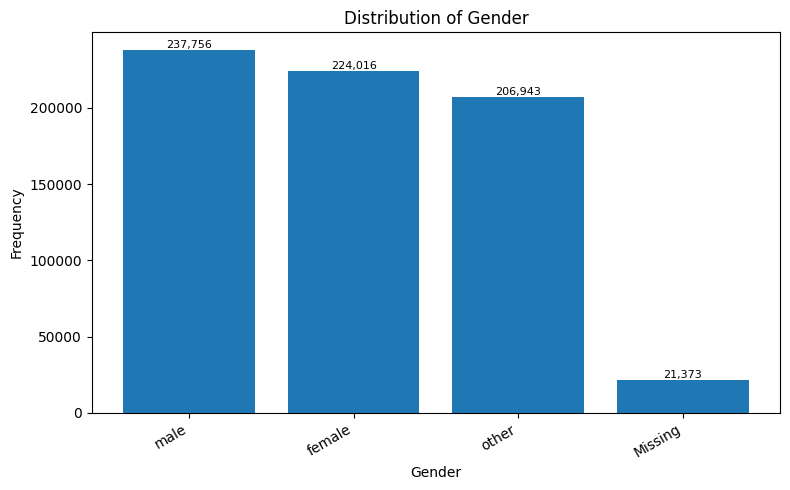

In [78]:
for feature in categorical_features:
    counts = (
        train_df[feature]
        .fillna("Missing")
        .value_counts()
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        counts.index.astype(str),
        counts.values
    )

    ax.set_title(
        f"Distribution of {feature.replace('_', ' ').title()}"
    )

    ax.set_xlabel(
        feature.replace("_", " ").title()
    )

    ax.set_ylabel("Frequency")

    plt.xticks(rotation=30, ha="right")

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height):,}",
            ha="center",
            va="bottom",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

In [79]:
categorical_target_tables = {}

for feature in categorical_features:
    cross_tab = pd.crosstab(
        train_df[feature].fillna("Missing"),
        train_df[TARGET],
        normalize="index"
    ).mul(100).round(2)

    categorical_target_tables[feature] = cross_tab

    print("=" * 70)
    print(f"{feature} vs {TARGET}")
    display(cross_tab)

diet_type vs health_condition


health_condition,at-risk,fit,unhealthy
diet_type,,,
Missing,86.76,5.09,8.16
balanced,85.14,6.12,8.74
non-veg,86.78,5.16,8.06
veg,85.67,6.04,8.30


stress_level vs health_condition


health_condition,at-risk,fit,unhealthy
stress_level,,,
Missing,85.89,5.75,8.36
high,71.78,0.35,27.87
low,79.67,20.06,0.28
medium,99.39,0.30,0.31


sleep_quality vs health_condition


...

health_condition,at-risk,fit,unhealthy
physical_activity_level,,,
Missing,85.94,5.72,8.34
active,74.31,17.16,8.53
moderate,91.15,0.31,8.54
sedentary,91.73,0.24,8.03


smoking_alcohol vs health_condition


health_condition,at-risk,fit,unhealthy
smoking_alcohol,,,
Missing,85.68,5.77,8.55
no,86.68,7.86,5.46
occasional,85.85,5.78,8.36
yes,85.10,3.70,11.20


gender vs health_condition


health_condition,at-risk,fit,unhealthy
gender,,,
Missing,85.83,5.57,8.60
female,85.74,5.71,8.55
male,85.70,6.26,8.05
other,86.21,5.29,8.50


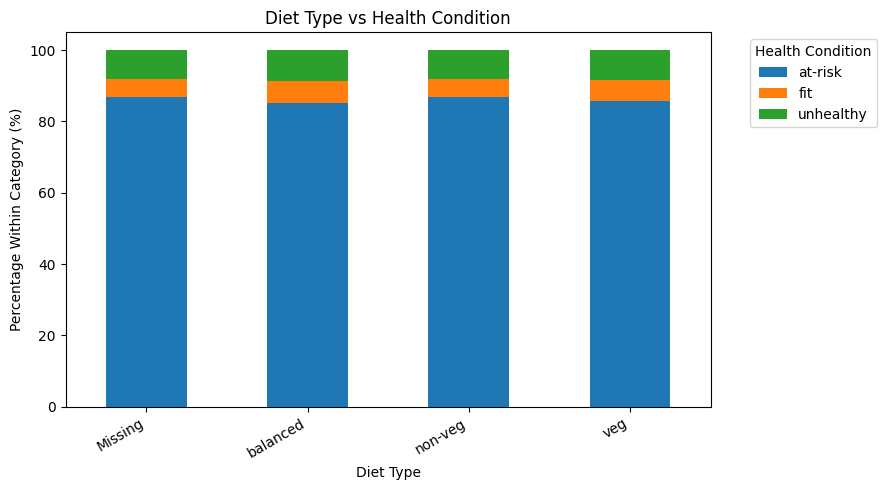

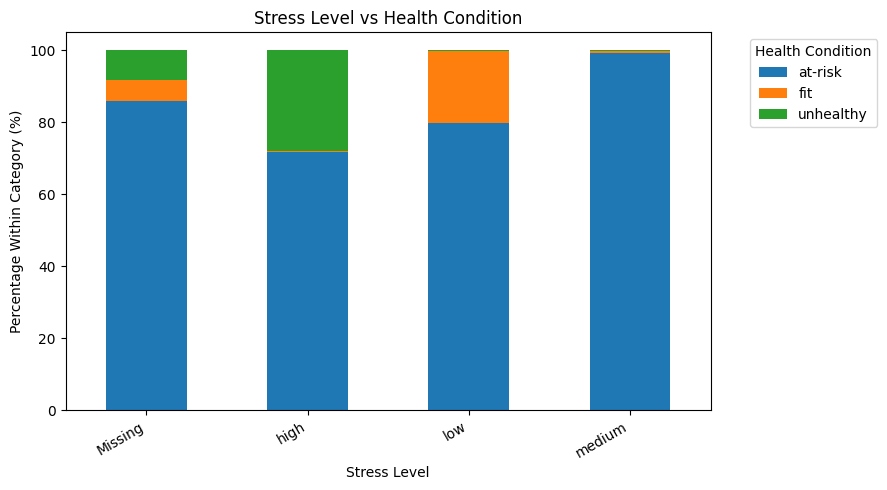

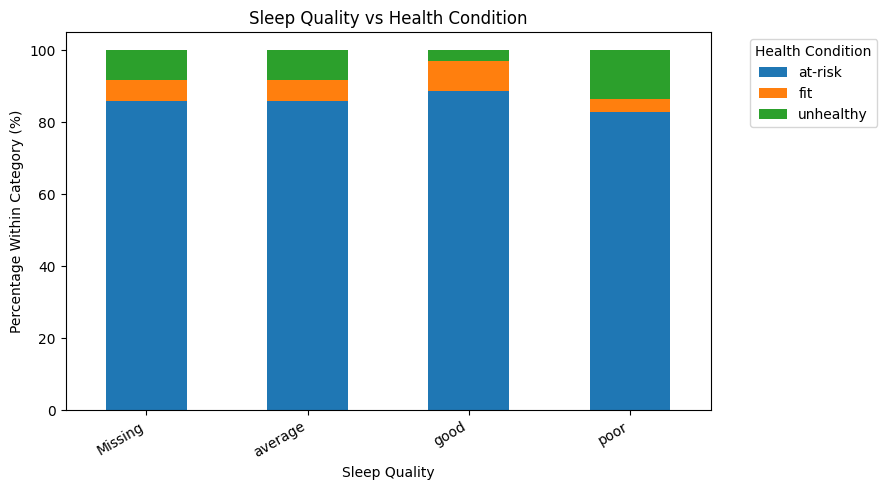

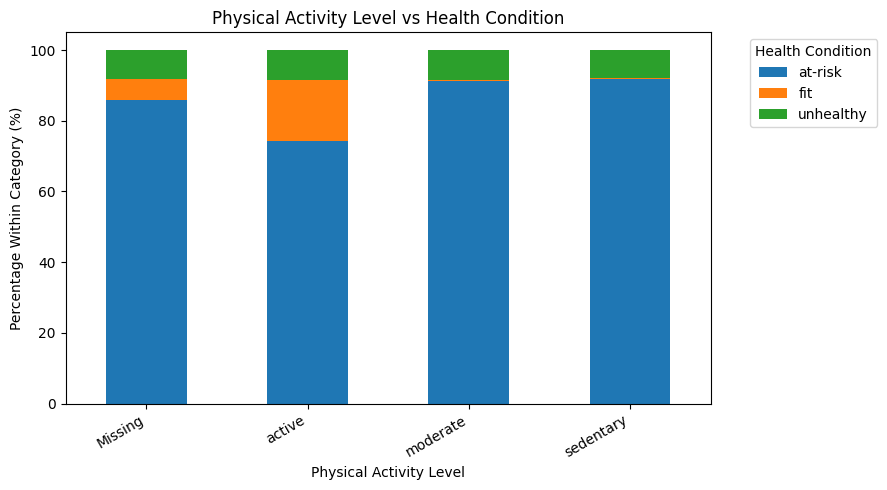

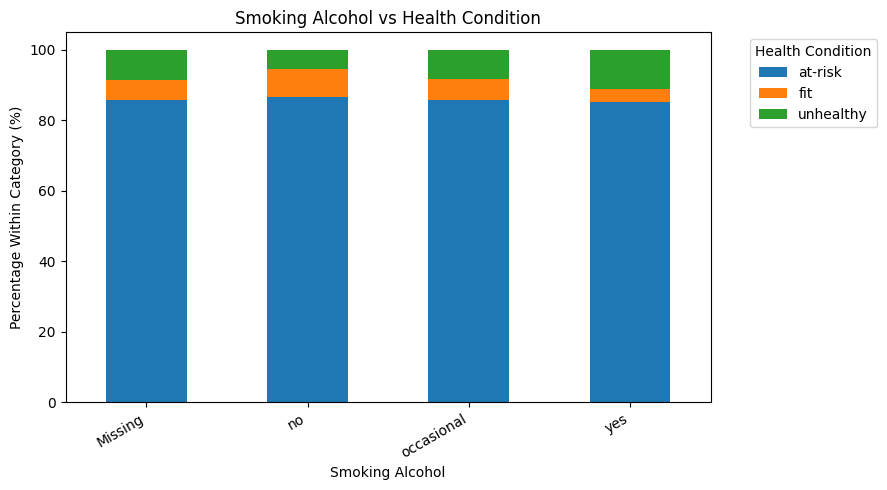

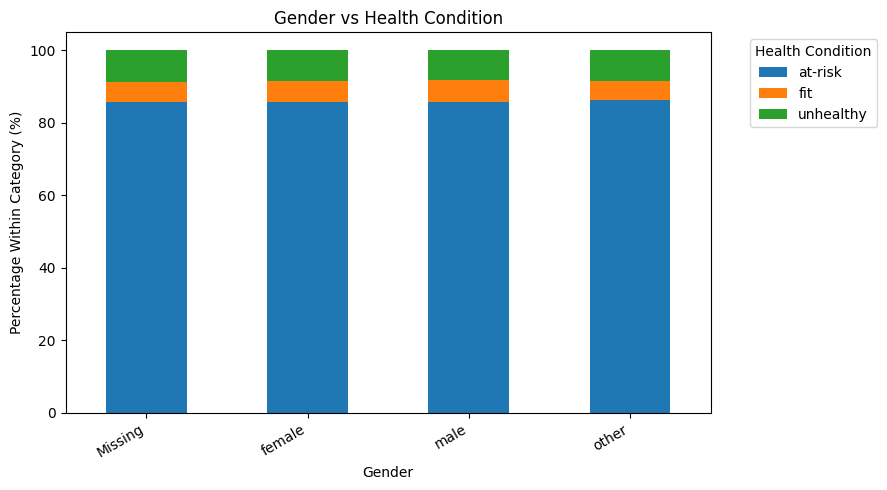

In [80]:
for feature in categorical_features:
    cross_tab = pd.crosstab(
        train_df[feature].fillna("Missing"),
        train_df[TARGET],
        normalize="index"
    ).mul(100)

    ax = cross_tab.plot(
        kind="bar",
        stacked=True,
        figsize=(9, 5)
    )

    ax.set_title(
        f"{feature.replace('_', ' ').title()} vs Health Condition"
    )

    ax.set_xlabel(
        feature.replace("_", " ").title()
    )

    ax.set_ylabel("Percentage Within Category (%)")

    plt.xticks(rotation=30, ha="right")
    plt.legend(
        title="Health Condition",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

In [81]:
classwise_means = (
    train_df
    .groupby(TARGET)[numerical_features]
    .mean()
    .round(3)
)

classwise_means

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
health_condition,,,,,,,
at-risk,7.086,75.101,22.950,2214.943,8406.706,37.965,2.189
fit,7.954,74.804,21.829,2363.992,11651.307,50.042,2.179
unhealthy,5.366,75.257,24.123,2245.420,8670.234,39.044,2.189


In [82]:
classwise_medians = (
    train_df
    .groupby(TARGET)[numerical_features]
    .median()
    .round(3)
)

classwise_medians

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
health_condition,,,,,,,
at-risk,7.03,75.1,22.96,2235.0,8483.0,38.6,2.18
fit,7.84,74.5,22.25,2345.0,12342.5,50.5,2.14
unhealthy,5.53,75.1,23.70,2255.0,8941.5,39.7,2.18


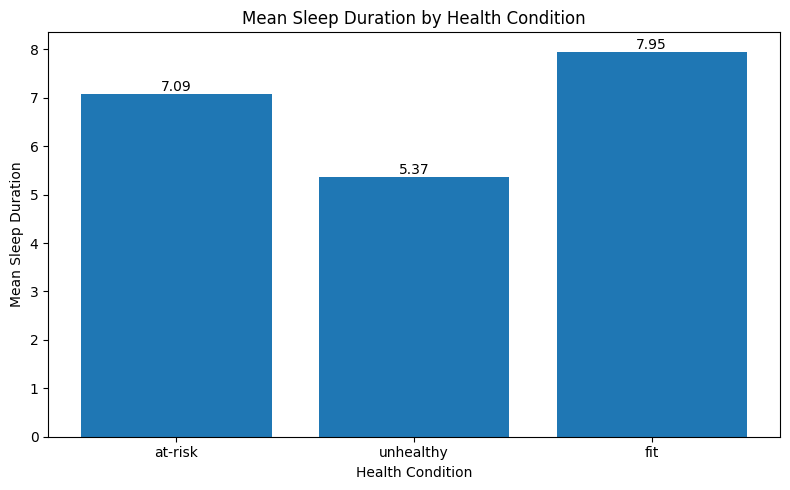

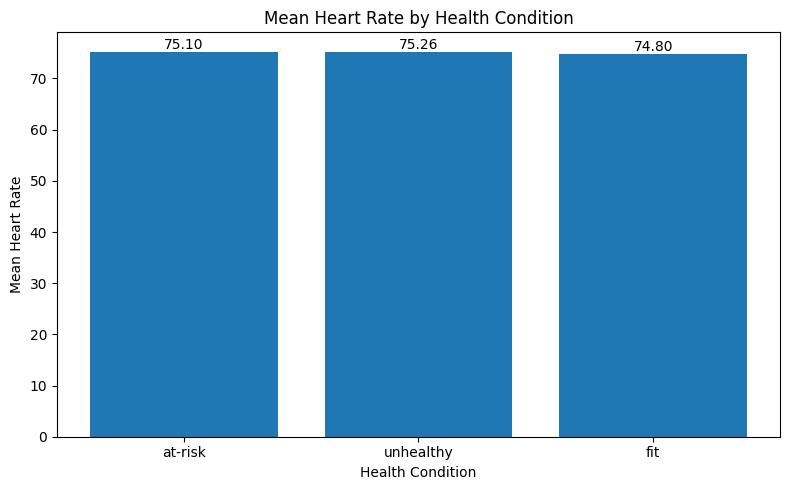

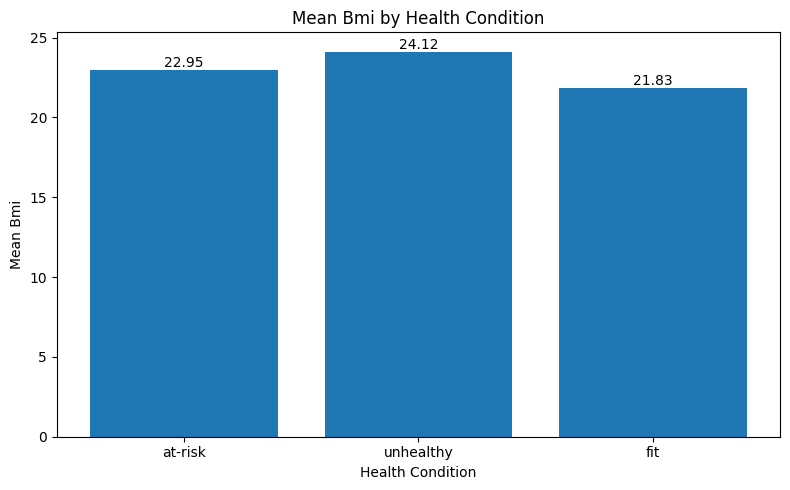

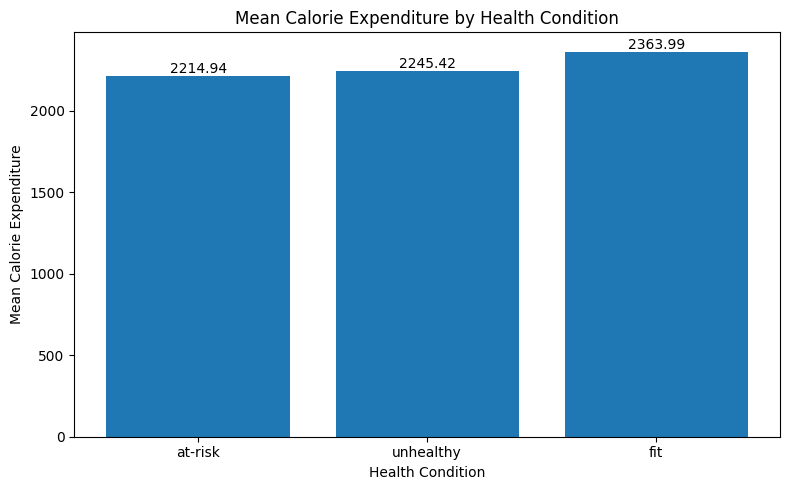

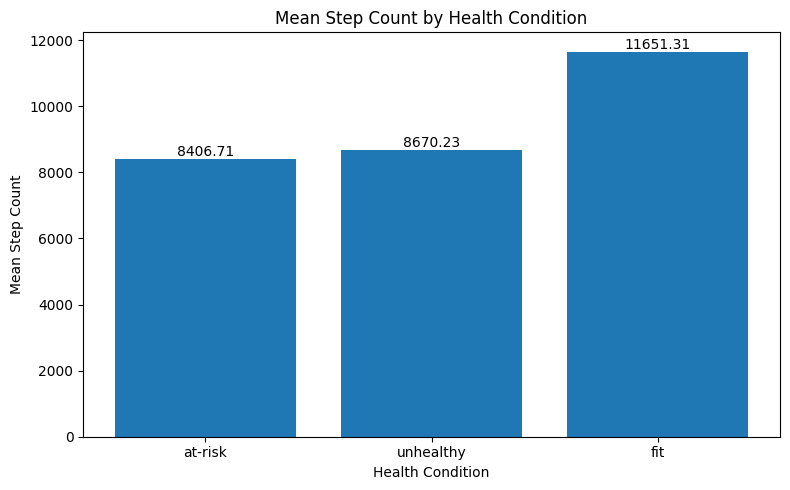

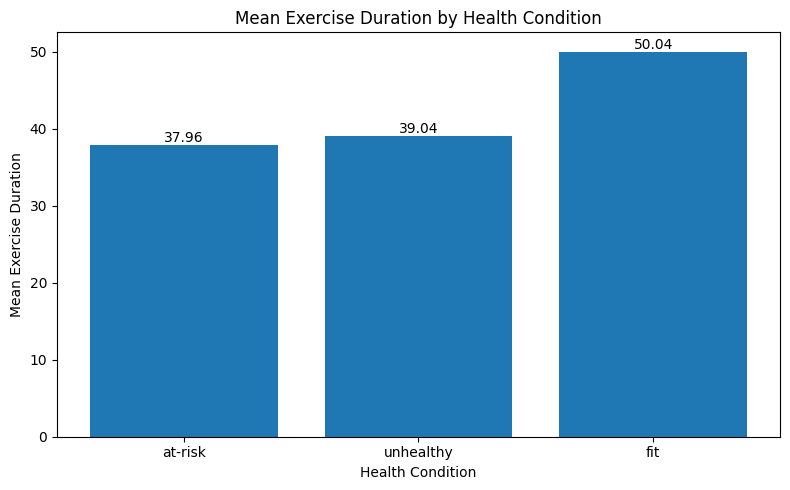

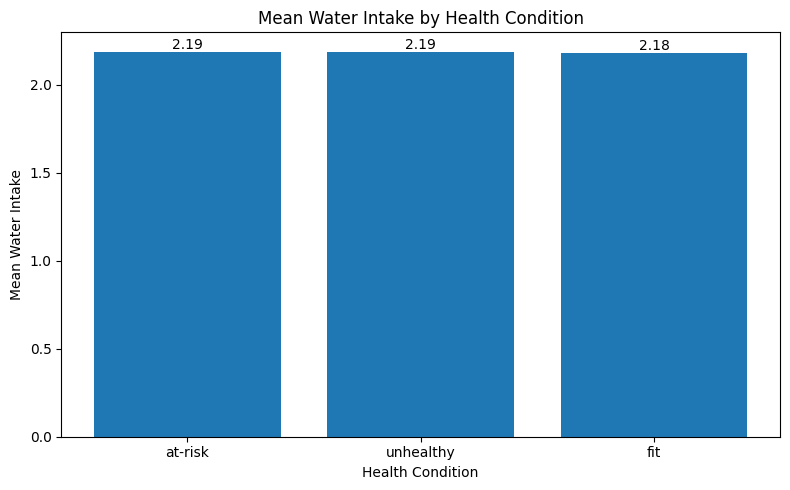

In [83]:
for feature in numerical_features:
    means = (
        train_df
        .groupby(TARGET)[feature]
        .mean()
        .reindex(target_order)
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        means.index,
        means.values
    )

    ax.set_title(
        f"Mean {feature.replace('_', ' ').title()} by Health Condition"
    )

    ax.set_xlabel("Health Condition")

    ax.set_ylabel(
        f"Mean {feature.replace('_', ' ').title()}"
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

In [84]:
correlation_matrix = (
    train_df[numerical_features]
    .corr()
    .round(2)
)

correlation_matrix

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
sleep_duration,1.00,-0.01,-0.07,-0.00,0.00,0.00,0.0
heart_rate,-0.01,1.00,0.00,-0.00,-0.01,-0.01,0.0
bmi,-0.07,0.00,1.00,0.12,-0.02,-0.02,0.0
calorie_expenditure,-0.00,-0.00,0.12,1.00,0.40,0.39,0.0
step_count,0.00,-0.01,-0.02,0.40,1.00,0.44,-0.0
exercise_duration,0.00,-0.01,-0.02,0.39,0.44,1.00,0.0
water_intake,0.00,0.00,0.00,0.00,-0.00,0.00,1.0


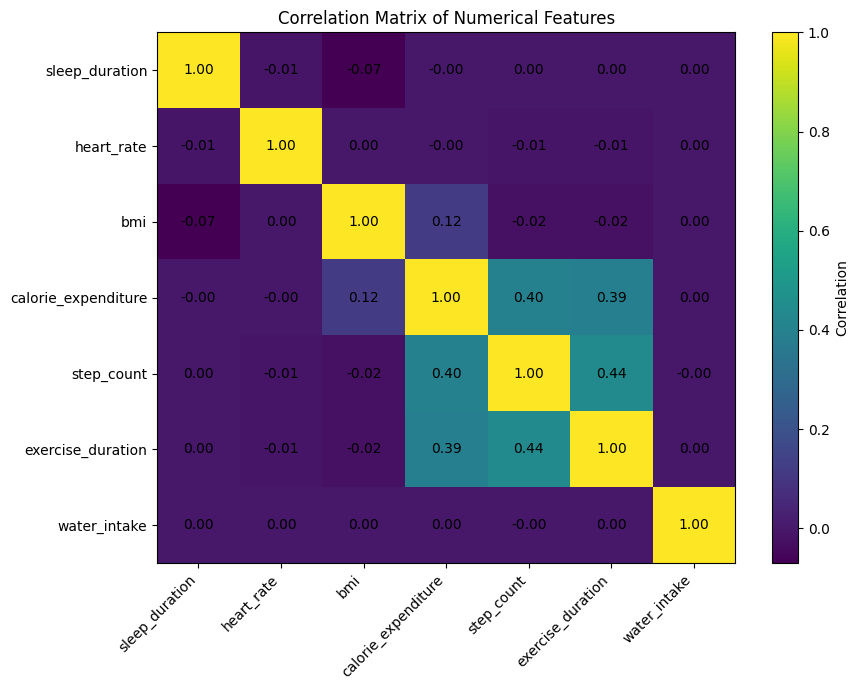

In [85]:
fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(
    correlation_matrix.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(correlation_matrix.columns))
)

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    range(len(correlation_matrix.index))
)

ax.set_yticklabels(
    correlation_matrix.index
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Correlation Matrix of Numerical Features")

fig.colorbar(
    image,
    ax=ax,
    label="Correlation"
)

plt.tight_layout()
plt.show()

In [86]:
corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(
                correlation_matrix.shape
            ),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

corr_pairs["Absolute Correlation"] = (
    corr_pairs["Correlation"].abs()
)

corr_pairs = corr_pairs.sort_values(
    "Absolute Correlation",
    ascending=False
)

corr_pairs.head(10)

,Feature 1,Feature 2,Correlation,Absolute Correlation
33,step_count,exercise_duration,0.44,0.44
25,calorie_expenditure,step_count,0.40,0.40
26,calorie_expenditure,exercise_duration,0.39,0.39
17,bmi,calorie_expenditure,0.12,0.12
2,sleep_duration,bmi,-0.07,0.07
19,bmi,exercise_duration,-0.02,0.02
18,bmi,step_count,-0.02,0.02
1,sleep_duration,heart_rate,-0.01,0.01
11,heart_rate,step_count,-0.01,0.01
12,heart_rate,exercise_duration,-0.01,0.01


### Correlation Analysis Interpretation

The correlation analysis evaluates linear relationships among numerical predictors. Strong correlations may indicate overlapping information and can affect linear or margin-based models differently from tree-based methods.

The correlation matrix will therefore be used to assess potential multicollinearity and feature redundancy. However, low Pearson correlation does not imply that a feature is uninformative, because non-linear relationships may still be captured by Random Forest, kernel-based SVM approaches, or the MLP Neural Network.

In [87]:
missing_by_target = {}

for feature in numerical_features + categorical_features:
    temp = (
        train_df
        .assign(
            is_missing=train_df[feature].isna()
        )
        .groupby(TARGET)["is_missing"]
        .mean()
        .mul(100)
        .round(2)
    )

    missing_by_target[feature] = temp

missing_by_target_df = pd.DataFrame(
    missing_by_target
).T

missing_by_target_df

health_condition,at-risk,fit,unhealthy
sleep_duration,11.02,10.94,10.97
heart_rate,1.15,1.09,1.00
bmi,2.08,2.86,0.71
calorie_expenditure,7.65,7.70,7.69
step_count,2.02,1.99,1.95
exercise_duration,0.99,1.05,1.06
water_intake,6.27,6.34,6.54
diet_type,1.01,0.88,0.98
stress_level,12.00,11.96,11.99
sleep_quality,8.46,8.53,8.31


In [88]:
missingness_difference = pd.DataFrame({
    "Minimum Missing %": missing_by_target_df.min(axis=1),
    "Maximum Missing %": missing_by_target_df.max(axis=1)
})

missingness_difference["Difference"] = (
    missingness_difference["Maximum Missing %"] -
    missingness_difference["Minimum Missing %"]
)

missingness_difference = (
    missingness_difference
    .sort_values(
        "Difference",
        ascending=False
    )
    .round(2)
)

missingness_difference

,Minimum Missing %,Maximum Missing %,Difference
bmi,0.71,2.86,2.15
water_intake,6.27,6.54,0.27
sleep_quality,8.31,8.53,0.22
gender,2.99,3.19,0.20
heart_rate,1.00,1.15,0.15
diet_type,0.88,1.01,0.13
smoking_alcohol,4.13,4.24,0.11
sleep_duration,10.94,11.02,0.08
step_count,1.95,2.02,0.07
exercise_duration,0.99,1.06,0.07


### Missingness and Target Relationship

Missingness is also examined across target classes to determine whether incomplete observations occur at approximately similar rates for all health-condition categories. Large differences in missingness rates between classes could indicate that missingness itself contains predictive information or reflects systematic data-generation patterns.

This analysis informs whether simple imputation is sufficient or whether missing-indicator features should be considered during later model experimentation.

In [89]:
class_counts = train_df[TARGET].value_counts()

majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

imbalance_ratio = (
    class_counts.max() /
    class_counts.min()
)

print("Majority Class:", majority_class)
print("Minority Class:", minority_class)
print(
    "Majority-to-Minority Ratio:",
    f"{imbalance_ratio:.2f}:1"
)

Majority Class: at-risk
Minority Class: fit
Majority-to-Minority Ratio: 14.89:1


In [90]:
majority_baseline_accuracy = (
    class_counts.max() /
    class_counts.sum()
)

print(
    "Naive Majority-Class Accuracy:",
    f"{majority_baseline_accuracy * 100:.2f}%"
)

Naive Majority-Class Accuracy: 85.87%


### Majority-Class Baseline Interpretation

A naive classifier that predicts the majority `at-risk` class for every observation would achieve approximately 85.87% accuracy without learning meaningful distinctions between health-condition categories.

This demonstrates why accuracy alone would be misleading for the present problem. A genuinely useful classifier should improve minority-class recognition while maintaining acceptable overall performance. Consequently, balanced accuracy, macro-averaged metrics, class-wise recall, and confusion matrices are central to the evaluation strategy.

## Key Exploratory Findings

The exploratory analysis identified several characteristics that directly affect the modelling strategy:

1. **Severe target imbalance:** The `at-risk` class accounts for 85.87% of observations, compared with 8.36% for `unhealthy` and 5.77% for `fit`.

2. **Misleading majority baseline:** Predicting only the majority class would already produce approximately 85.87% accuracy, demonstrating that accuracy alone is unsuitable for model selection.

3. **Substantial missing data:** The dataset contains 449,496 missing values, equivalent to approximately 4.34% of all cells.

4. **Uneven feature-level missingness:** `stress_level`, `sleep_duration`, and `sleep_quality` exhibit the highest missing percentages.

5. **Mixed feature types:** The predictive dataset contains seven numerical and six categorical features, requiring a structured preprocessing pipeline.

6. **No exact duplicate rows:** The initial inspection found zero duplicated observations.

7. **Large dataset size:** The training dataset contains 690,088 observations. This scale affects algorithm selection and computational feasibility, particularly for conventional kernel-based SVM training.

8. **Potential outliers require cautious interpretation:** IQR-based extreme observations should not be automatically removed because unusual values may represent genuine health and lifestyle variation.

9. **Feature relationships differ in form:** Linear correlation analysis alone cannot capture all potentially useful non-linear relationships, supporting comparison between linear, ensemble, margin-based, and neural models.

10. **Missingness may require further modelling consideration:** Class-specific missingness analysis can indicate whether missing-value indicators should be evaluated in addition to standard imputation.

## How EDA Influenced Model Design

The exploratory findings directly influenced the planned modelling strategy.

### 1. Class-Imbalance-Aware Evaluation

Because the target distribution is highly imbalanced, model selection will not rely solely on overall accuracy. Balanced accuracy, macro precision, macro recall, macro F1-score, class-wise metrics, and confusion matrices will be used. The official Kaggle metric will also be considered for competition-oriented evaluation.

### 2. Imputation Strategy

The presence of missing values makes complete-case deletion potentially wasteful. Numerical variables will initially be handled using median imputation, while categorical variables will use a most-frequent baseline strategy. Imputation will be fitted only on training data within reproducible pipelines to reduce data leakage.

### 3. Categorical Encoding

Six categorical predictors require numerical transformation. One-hot encoding is an appropriate initial strategy because each categorical feature contains only a small number of observed categories.

### 4. Feature Scaling

The numerical variables operate on substantially different scales. For example, step counts are measured in thousands, whereas water intake is represented by much smaller numerical values. Standardisation will therefore be applied to Logistic Regression, SVM, and MLP pipelines. Random Forest does not require the same degree of scale normalisation.

### 5. Model Diversity

The EDA supports comparison of models with different learning characteristics:

- Logistic Regression provides an interpretable linear baseline.
- Random Forest captures non-linear interactions and is relatively robust to feature scaling.
- SVM investigates margin-based decision boundaries but requires careful consideration of scalability.
- MLP Neural Network evaluates whether learned non-linear representations improve classification performance.

### 6. Computational Scalability

The large training dataset makes conventional kernel SVM training potentially expensive. The SVM implementation will therefore be selected and documented with computational feasibility in mind rather than applying an impractical configuration without justification.

### 7. Outlier Treatment

Potential outliers will not be automatically deleted. Their plausibility and impact will be considered because unusual observations may contain useful information, particularly for minority health-condition classes.

Overall, the EDA demonstrates that preprocessing and evaluation choices must be model-specific and data-driven rather than uniformly applied across all algorithms.

In [91]:
OUTPUT_METRICS_DIR = (
    PROJECT_ROOT /
    "outputs" /
    "metrics"
)

OUTPUT_METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

target_distribution.to_csv(
    OUTPUT_METRICS_DIR /
    "target_distribution.csv"
)

missing_summary.to_csv(
    OUTPUT_METRICS_DIR /
    "missing_value_summary.csv"
)

outlier_summary.to_csv(
    OUTPUT_METRICS_DIR /
    "outlier_summary.csv",
    index=False
)

correlation_matrix.to_csv(
    OUTPUT_METRICS_DIR /
    "correlation_matrix.csv"
)

missingness_difference.to_csv(
    OUTPUT_METRICS_DIR /
    "missingness_by_target_difference.csv"
)

print("EDA summary tables saved successfully.")

EDA summary tables saved successfully.


## EDA Conclusion

The exploratory analysis confirms that the student health risk dataset presents a challenging multi-class classification problem characterised by severe target imbalance, missing values, mixed numerical and categorical predictors, large sample size, and potentially non-linear relationships.

These findings justify the use of structured preprocessing pipelines and a comparative modelling strategy involving Logistic Regression, Random Forest, Support Vector Machine, and an MLP Neural Network. The next stage will implement leakage-resistant preprocessing procedures tailored to the requirements of the four models.